# AI Description → CLIP Text Encoder → VA Removal → Searchlight RSA

**Pipeline:**
1. Load AI-generated image descriptions (from GPT batch output CSV)
2. Feed descriptions through CLIP ViT-B/32 text encoder to get 512-dim embeddings
3. Load VA scores and remove emotion-related variance from embeddings (embedding-level projection)
4. Build RDMs: raw, embedding-projected, and RDM-regressed
5. Run whole-brain searchlight RSA against fMRI data (20 subjects) for each cleaned RDM
6. Group-level t-map with FDR correction

This is a standalone notebook. All paths assume you are running from
`N:\Experimental_Data\yujunchen\projects\IAPS_AI_RDM\`.

In [16]:
import os
import numpy as np
import pandas as pd
import pickle
import torch
import clip
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from nilearn.image import new_img_like
import nilearn.image as nlimg
from nilearn import plotting
from scipy.stats import ttest_1samp, spearmanr
from statsmodels.stats.multitest import fdrcorrection
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs
from rsatoolbox.util.searchlight import evaluate_models_searchlight
from rsatoolbox.model import ModelFixed
from rsatoolbox.inference import eval_fixed

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

os.makedirs('./outputs/tBrainmap', exist_ok=True)

Device: cpu


In [17]:
# =====================================================================
# CONFIG
# =====================================================================

# CSV output from the description batch script (3 columns: image_id, model, description)
DESCRIPTION_CSV = r"N:\Experimental_Data\yujunchen\projects\IAPS_AI_RDM\outputs\descriptions_iaps60_grayscale_gpt-5.2_20260518_182355.csv"

# IAPS image order file (determines row order in the RDM)
IAPS_ORDER_CSV = r"..\IAPS_Searchlight\IAPS_60_pnu.csv"

# Trial file with VA scores
IAPS_TRIAL_CSV = r"..\IAPS_behavioral_RDM\fmri_conditions_trial_ordered.csv"

# fMRI searchlight data
FMRI_DATA_DIR = r"."
TMP_IMG_PATH  = os.path.join(FMRI_DATA_DIR, "tmp.img")
MASK_PATH     = os.path.join(FMRI_DATA_DIR, "mask.npy")
ALLSUB_PATH   = os.path.join(FMRI_DATA_DIR, "allsub_avg.npy")

# Searchlight parameters
SL_RADIUS    = 5
SL_THRESHOLD = 0.5
N_JOBS       = 6

# Statistics
FDR_ALPHAS        = [0.05, 0.01, 0.001]
CLUSTER_THRESHOLD = 30

# CLIP model
CLIP_MODEL = "ViT-B/32"

N_STIMULI = 60

In [18]:
def upper_tri(RDM):
    """Extract upper triangle of a square RDM (excluding diagonal)."""
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]


def rdm_from_features(features, metric='correlation'):
    """Build an RDM from a feature matrix (n_stimuli x n_features)."""
    rdm = pairwise_distances(features, metric=metric)
    np.fill_diagonal(rdm, 0)
    return rdm


def normalize_rdm(rdm):
    """Min-max normalize an RDM to [0, 1]."""
    mn, mx = rdm.min(), rdm.max()
    if mx - mn == 0:
        return rdm
    return (rdm - mn) / (mx - mn)

## 1. Load VA Scores

In [19]:
# Extract unique stimuli with VA scores, sorted Pl/Nt/Up by stim_order
iaps_file = pd.read_csv(IAPS_TRIAL_CSV)

iaps_unique_count = (
    iaps_file[['iaps_id', 'type', 'category', 'stim_order', 'Mean_Valence', 'Mean_Arousal']]
    .value_counts()
    .reset_index(name='count')
)
iaps_unique_count['type'] = pd.Categorical(iaps_unique_count['type'], ['Pl', 'Nt', 'Up'])
iaps_unique = iaps_unique_count.sort_values(by=['type', 'stim_order'])
iaps_behave_raw = iaps_unique.drop(columns=['count']).reset_index(drop=True)

assert len(iaps_behave_raw) == N_STIMULI, f"Expected {N_STIMULI}, got {len(iaps_behave_raw)}"

va_scores = iaps_behave_raw[['Mean_Valence', 'Mean_Arousal']].values  # (60, 2)
print(f"VA scores shape: {va_scores.shape}")
print(f"Valence range: {va_scores[:,0].min():.2f} - {va_scores[:,0].max():.2f}")
print(f"Arousal range: {va_scores[:,1].min():.2f} - {va_scores[:,1].max():.2f}")

# Build VA RDM
va_rdm = rdm_from_features(va_scores, metric='euclidean')
va_rdm = normalize_rdm(va_rdm)
print(f"VA RDM shape: {va_rdm.shape}")

VA scores shape: (60, 2)
Valence range: 1.45 - 7.83
Arousal range: 2.86 - 7.35
VA RDM shape: (60, 60)


## 2. Load AI-generated descriptions and align to IAPS order

In [20]:
# Load the IAPS ordering
iaps_order = pd.read_csv(IAPS_ORDER_CSV)
iaps_ids = [str(x) for x in iaps_order['iaps_id']]
print(f"IAPS order: {len(iaps_ids)} images")
print(f"First 5: {iaps_ids[:5]}")

# Load descriptions
desc_df = pd.read_csv(DESCRIPTION_CSV)
print(f"\nDescriptions loaded: {len(desc_df)} rows")
print(f"Columns: {list(desc_df.columns)}")
print(f"Model used: {desc_df['model'].unique()}")

# Make image_id string for matching
desc_df['image_id'] = desc_df['image_id'].astype(str)

# Check for missing descriptions
missing = desc_df['description'].isna().sum()
if missing > 0:
    print(f"\nWARNING: {missing} images have no description!")
    print(desc_df[desc_df['description'].isna()]['image_id'].tolist())

# Align descriptions to IAPS order
desc_df = desc_df.set_index('image_id')
descriptions = [desc_df.loc[iid, 'description'] for iid in iaps_ids]
print(f"\nAligned {len(descriptions)} descriptions to IAPS order")
print(f"Sample: {descriptions[0][:100]}...")

IAPS order: 60 images
First 5: ['4680', '4641', '8250', '8186', '4626']

Descriptions loaded: 60 rows
Columns: ['image_id', 'model', 'description']
Model used: ['gpt-5.2']

Aligned 60 descriptions to IAPS order
Sample: A  close-up shows two nude people lying close together, with the upper person leaning over the lower...


## 3. Encode descriptions with CLIP text encoder

In [21]:
# Load CLIP model
clip_model, _ = clip.load(CLIP_MODEL, device=device)
clip_model.eval()

# Tokenize and encode all descriptions
text_tokens = clip.tokenize(descriptions, truncate=True).to(device)

with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

clip_desc_embeddings = text_features.cpu().numpy().astype(np.float32)
print(f"CLIP text embeddings shape: {clip_desc_embeddings.shape}")  # (60, 512)

# Save raw embeddings
with open('./outputs/clip_text_from_ai_descriptions.pkl', 'wb') as f:
    pickle.dump(clip_desc_embeddings, f)
print("Saved: clip_text_from_ai_descriptions.pkl")

CLIP text embeddings shape: (60, 512)
Saved: clip_text_from_ai_descriptions.pkl


## 4. Build raw description RDM and check emotion leakage

In [22]:
desc_rdm_raw = rdm_from_features(clip_desc_embeddings, metric='correlation')
print(f"Raw description RDM shape: {desc_rdm_raw.shape}")

r_raw, p_raw = spearmanr(upper_tri(desc_rdm_raw), upper_tri(va_rdm))
print(f"Raw description RDM vs VA RDM: r = {r_raw:.3f}  (p = {p_raw:.2e})")
print(f"This is how much emotion leaks into the non-emotion description embeddings.")

Raw description RDM shape: (60, 60)
Raw description RDM vs VA RDM: r = 0.103  (p = 1.55e-05)
This is how much emotion leaks into the non-emotion description embeddings.


In [34]:
desc_rdm_raw = rdm_from_features(clip_desc_embeddings, metric='correlation')
print(f"Raw description RDM shape: {desc_rdm_raw.shape}")

r_raw, p_raw = spearmanr(upper_tri(desc_rdm_raw), upper_tri(va_rdm))
print(f"Raw description RDM vs VA RDM: r = {r_raw:.3f}  (p = {p_raw:.2e})")
print(f"This is how much emotion leaks into the non-emotion description embeddings.")

# Check how much VA can be linearly predicted from raw embeddings
# (OLS will overfit with 512d > 60 samples, so use Ridge)
ridge_raw = Ridge(alpha=1.0).fit(clip_desc_embeddings, va_scores)
r2_raw = ridge_raw.score(clip_desc_embeddings, va_scores)
print(f"\nRidge R^2 (raw 512d embeddings -> VA): {r2_raw:.4f}")

# Also check in PCA-reduced space for a fairer estimate
from sklearn.model_selection import cross_val_score
pca_check = PCA(n_components=0.95, svd_solver='full')
emb_pca_check = pca_check.fit_transform(clip_desc_embeddings)
cv_r2 = cross_val_score(Ridge(alpha=1.0), emb_pca_check, va_scores, cv=5, scoring='r2').mean()
print(f"5-fold CV Ridge R^2 (PCA embeddings -> VA): {cv_r2:.4f}")
print(f"  (this is the generalizable emotion content in the embeddings)")

Raw description RDM shape: (60, 60)
Raw description RDM vs VA RDM: r = 0.103  (p = 1.55e-05)
This is how much emotion leaks into the non-emotion description embeddings.

Ridge R^2 (raw 512d embeddings -> VA): 0.7121
5-fold CV Ridge R^2 (PCA embeddings -> VA): -2.5677
  (this is the generalizable emotion content in the embeddings)


## 5A. Embedding-level projection: remove VA from embedding space

With 512 dims and only 60 stimuli, OLS perfectly fits anything (R²=1),
making the regression coefficients meaningless. Solution: first reduce
embeddings via PCA to fewer components than n_stimuli, then regress VA
out in that reduced space, then reconstruct.

In [23]:
# --- Step 1: PCA to reduce 512-d to a safe dimensionality ---
# Keep enough PCs to preserve 95% variance, but cap at n_stimuli - 3
# so the regression is well-conditioned
pca = PCA(n_components=0.95, svd_solver='full')
emb_pca = pca.fit_transform(clip_desc_embeddings)  # (60, k) where k < 60
n_pcs = emb_pca.shape[1]
print(f"PCA: {clip_desc_embeddings.shape[1]}d -> {n_pcs}d  "
      f"({pca.explained_variance_ratio_.sum()*100:.1f}% variance retained)")

# Safety: if PCA still gives too many components, hard cap
max_pcs = N_STIMULI - 3  # leave degrees of freedom for regression
if n_pcs > max_pcs:
    print(f"Capping from {n_pcs} to {max_pcs} PCs")
    pca = PCA(n_components=max_pcs)
    emb_pca = pca.fit_transform(clip_desc_embeddings)
    n_pcs = emb_pca.shape[1]

# --- Step 2: Ridge regression in PCA space (embedding -> VA) ---
# Ridge avoids overfitting even if n_pcs is close to n_stimuli
ridge = Ridge(alpha=1.0).fit(emb_pca, va_scores)
r2_before = ridge.score(emb_pca, va_scores)
print(f"Ridge R^2 (PCA embeddings -> VA): {r2_before:.4f}")

# --- Step 3: Project out VA-predictive subspace in PCA space ---
coefs = ridge.coef_  # (2, n_pcs)
Q, _ = np.linalg.qr(coefs.T)  # (n_pcs, 2) orthonormal basis of VA subspace

emb_pca_clean = emb_pca - emb_pca @ Q @ Q.T

# --- Step 4: Reconstruct back to 512-d ---
embeddings_clean = pca.inverse_transform(emb_pca_clean)
print(f"Clean embeddings shape: {embeddings_clean.shape}")

# --- Verify ---
# Check in PCA space (the space where projection was done)
ridge_check = Ridge(alpha=1.0).fit(emb_pca_clean, va_scores)
r2_after_pca = ridge_check.score(emb_pca_clean, va_scores)
print(f"Post-projection Ridge R^2 in PCA space: {r2_after_pca:.4f}  (should be much lower)")

# Also check OLS in PCA space for comparison
ols_check = LinearRegression().fit(emb_pca_clean, va_scores)
r2_after_ols = ols_check.score(emb_pca_clean, va_scores)
print(f"Post-projection OLS R^2 in PCA space:   {r2_after_ols:.4f}")

# --- Build RDM from cleaned embeddings ---
desc_rdm_embproj = rdm_from_features(embeddings_clean, metric='correlation')

r_embproj, p_embproj = spearmanr(upper_tri(desc_rdm_embproj), upper_tri(va_rdm))
print(f"\nEmbedding-projected RDM vs VA RDM: r = {r_embproj:.3f}  (was {r_raw:.3f})")

# Save cleaned embeddings
with open('./outputs/clip_text_ai_desc_VA_projected.pkl', 'wb') as f:
    pickle.dump(embeddings_clean, f)
print("Saved: clip_text_ai_desc_VA_projected.pkl")

PCA: 512d -> 42d  (95.1% variance retained)
Ridge R^2 (PCA embeddings -> VA): 0.6971
Clean embeddings shape: (60, 512)
Post-projection Ridge R^2 in PCA space: 0.0860  (should be much lower)
Post-projection OLS R^2 in PCA space:   0.1203

Embedding-projected RDM vs VA RDM: r = -0.135  (was 0.103)
Saved: clip_text_ai_desc_VA_projected.pkl


## 5B. RDM-level regression: regress VA RDM out of description RDM

Simpler alternative that operates directly on pairwise distances.

In [24]:
desc_vec = upper_tri(desc_rdm_raw)
va_vec = upper_tri(va_rdm)

reg_rdm = LinearRegression().fit(va_vec.reshape(-1, 1), desc_vec)
desc_resid_vec = desc_vec - reg_rdm.predict(va_vec.reshape(-1, 1))

# Reconstruct symmetric residual RDM
desc_rdm_rdmproj = np.zeros((N_STIMULI, N_STIMULI))
r_idx, c_idx = np.triu_indices(N_STIMULI, 1)
desc_rdm_rdmproj[r_idx, c_idx] = desc_resid_vec
desc_rdm_rdmproj[c_idx, r_idx] = desc_resid_vec

r_rdmproj, p_rdmproj = spearmanr(upper_tri(desc_rdm_rdmproj), va_vec)
print(f"RDM-regressed RDM vs VA RDM: r = {r_rdmproj:.3f}  (was {r_raw:.3f})")

RDM-regressed RDM vs VA RDM: r = -0.034  (was 0.103)


## 6. Visualize: before vs after emotion removal

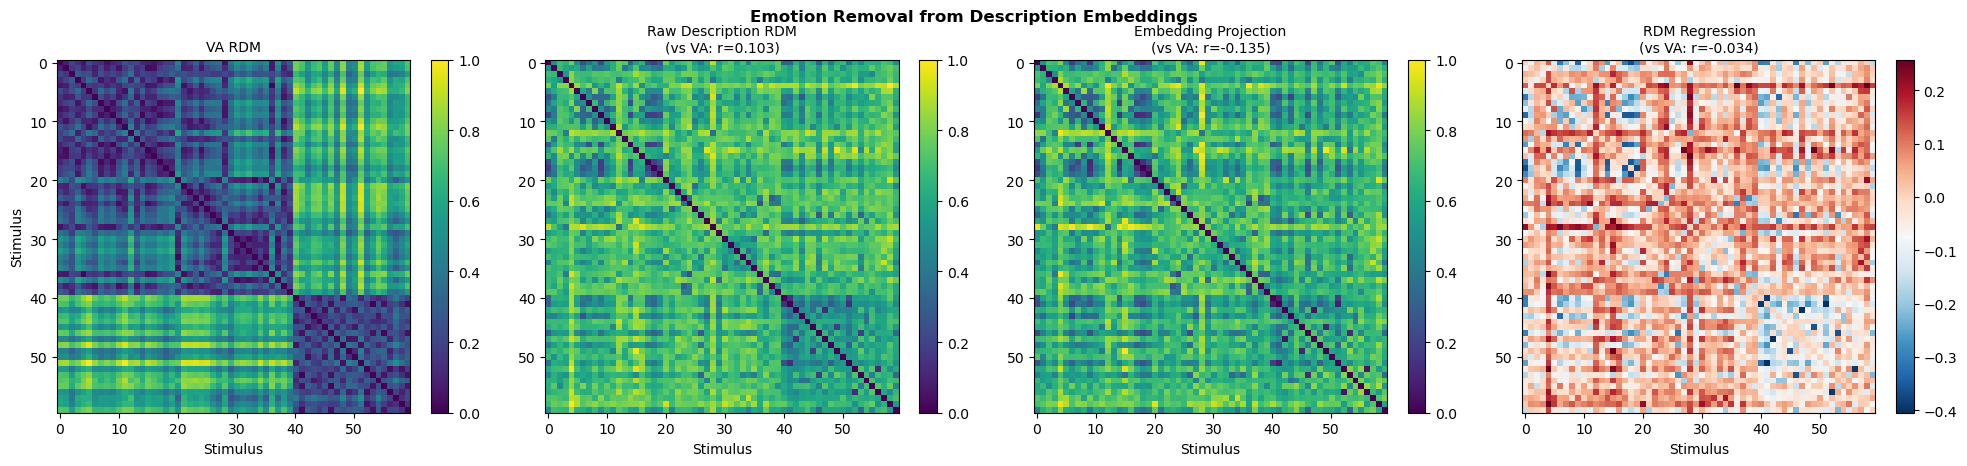

RDM                        vs VA (r)            p
--------------------------------------------------
Raw Description                0.103     1.55e-05
Embedding Projection          -0.135     1.13e-08
RDM Regression                -0.034     1.57e-01


In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

im0 = axes[0].imshow(va_rdm, cmap='viridis', aspect='equal')
axes[0].set_title('VA RDM', fontsize=10)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(normalize_rdm(desc_rdm_raw), cmap='viridis', aspect='equal')
axes[1].set_title(f'Raw Description RDM\n(vs VA: r={r_raw:.3f})', fontsize=10)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(normalize_rdm(desc_rdm_embproj), cmap='viridis', aspect='equal')
axes[2].set_title(f'Embedding Projection\n(vs VA: r={r_embproj:.3f})', fontsize=10)
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(desc_rdm_rdmproj, cmap='RdBu_r', aspect='equal')
axes[3].set_title(f'RDM Regression\n(vs VA: r={r_rdmproj:.3f})', fontsize=10)
plt.colorbar(im3, ax=axes[3], fraction=0.046)

for ax in axes:
    ax.set_xlabel('Stimulus')
axes[0].set_ylabel('Stimulus')

plt.suptitle('Emotion Removal from Description Embeddings', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/emotion_removal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'RDM':<25s} {'vs VA (r)':>10s} {'p':>12s}")
print('-' * 50)
print(f"{'Raw Description':<25s} {r_raw:>10.3f} {p_raw:>12.2e}")
print(f"{'Embedding Projection':<25s} {r_embproj:>10.3f} {p_embproj:>12.2e}")
print(f"{'RDM Regression':<25s} {r_rdmproj:>10.3f} {p_rdmproj:>12.2e}")

## 7. Save all RDMs

In [26]:
pd.DataFrame(desc_rdm_raw, index=iaps_ids, columns=iaps_ids).to_csv(
    './outputs/rdm_CLIP_AI_desc_raw.csv')
pd.DataFrame(desc_rdm_embproj, index=iaps_ids, columns=iaps_ids).to_csv(
    './outputs/rdm_CLIP_AI_desc_VA_embprojected.csv')
pd.DataFrame(desc_rdm_rdmproj, index=iaps_ids, columns=iaps_ids).to_csv(
    './outputs/rdm_CLIP_AI_desc_VA_rdmregressed.csv')
print('Saved all 3 RDMs.')

Saved all 3 RDMs.


## 8. Load fMRI data and build searchlight

In [27]:
tmp_img = nib.load(TMP_IMG_PATH)
mask = np.load(MASK_PATH)
allsub_avg = np.load(ALLSUB_PATH, allow_pickle=True)
centers, neighbors = get_volume_searchlight(mask, radius=SL_RADIUS, threshold=SL_THRESHOLD)

print(f"Mask shape: {mask.shape}")
print(f"Subject data shape: {allsub_avg.shape}")
print(f"Searchlight centers: {len(centers)}")

Finding searchlights...: 100%|██████████| 59159/59159 [00:07<00:00, 7771.92it/s]


Found 56949 searchlights
Mask shape: (53, 63, 46)
Subject data shape: (20, 60, 153594)
Searchlight centers: 56949


## 9. Searchlight RSA functions

In [28]:
def run_searchlight_for_model(model_name, model_rdm, allsub_avg, centers, neighbors, mask):
    """
    Run searchlight RSA for a single model RDM across all subjects.
    Returns eval_score_list (n_subjects, n_centers) and voxel_indices.
    """
    model_obj = ModelFixed(model_name, upper_tri(model_rdm))

    eval_score_list = []
    RDM_brain_list = []
    x, y, z = mask.shape

    for i in tqdm(range(allsub_avg.shape[0]), desc=f'{model_name}'):
        subj_data = np.nan_to_num(allsub_avg[i])
        image_value = np.arange(subj_data.shape[0])

        SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')

        eval_results = evaluate_models_searchlight(SL_RDM, model_obj, eval_fixed, method='spearman', n_jobs=N_JOBS)
        eval_score = [float(e.evaluations) for e in eval_results]

        RDM_brain = np.zeros(x * y * z)
        RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
        RDM_brain = RDM_brain.reshape(x, y, z)

        eval_score_list.append(eval_score)
        RDM_brain_list.append(RDM_brain)

    voxel_indices = np.array(SL_RDM.rdm_descriptors['voxel_index'])
    return np.array(eval_score_list), RDM_brain_list, voxel_indices


def compute_tmap_from_scores(eval_scores, voxel_indices, mask_shape, tmp_img,
                             fdr_alpha=0.001, cluster_threshold=30,
                             model_name='', t_value_threshold=None):
    """
    Fisher z-transform -> one-sample t-test -> FDR correction
    -> optional t threshold -> 3D t-map -> cluster threshold.
    """
    epsilon = 1e-10
    scores_clipped = np.clip(eval_scores, -1 + epsilon, 1 - epsilon)
    fisher_z = np.arctanh(scores_clipped)

    t_stats, p_values = ttest_1samp(fisher_z, 0, axis=0, nan_policy='omit')

    rejected, p_fdr = fdrcorrection(p_values, alpha=fdr_alpha)
    sig_mask = rejected

    if t_value_threshold is not None:
        sig_mask = sig_mask & (t_stats >= t_value_threshold)
        print(f"{model_name}: {np.sum(sig_mask)} significant voxels "
              f"(FDR q < {fdr_alpha} AND t >= {t_value_threshold})")
    else:
        print(f"{model_name}: {np.sum(sig_mask)} significant voxels "
              f"(FDR q < {fdr_alpha})")

    sig_voxels = np.where(sig_mask)[0]

    x, y, z = mask_shape
    t_map = np.full(x * y * z, np.nan)
    t_map[voxel_indices[sig_voxels]] = t_stats[sig_voxels]
    t_map_3d = t_map.reshape(x, y, z)

    t_map_3d[t_map_3d < 0] = np.nan

    t_img = new_img_like(tmp_img, t_map_3d)

    t_img_cluster = nlimg.threshold_img(
        t_img,
        threshold=0,
        cluster_threshold=cluster_threshold
    )

    return t_img_cluster, t_stats, p_fdr

## 10. Run searchlight RSA for all RDMs

This runs the searchlight for:
1. VA RDM (valence-arousal)
2. Raw description RDM (emotion still present)
3. Embedding-projected RDM (VA removed via Ridge + PCA)
4. RDM-regressed RDM (VA removed from distance matrix)

In [29]:
models_to_run = {
    'VA':                       va_rdm,
    'CLIP_AI_desc_raw':         desc_rdm_raw,
    'CLIP_AI_desc_VA_embproj':  desc_rdm_embproj,
    'CLIP_AI_desc_VA_rdmreg':   desc_rdm_rdmproj,
}

results = {}

for model_name, model_rdm in models_to_run.items():
    print(f"\n{'='*60}")
    print(f"  Running searchlight for: {model_name}")
    print(f"{'='*60}")

    eval_scores, rdm_brains, voxel_ids = run_searchlight_for_model(
        model_name, model_rdm, allsub_avg, centers, neighbors, mask
    )

    # Save per-subject eval scores
    pd.DataFrame(eval_scores).to_csv(f'./outputs/20sub_SL_eval_{model_name}.csv')
    np.save(f'./outputs/20sub_SL_eval_{model_name}.npy', eval_scores)
    print(f"Saved. Shape: {eval_scores.shape}")

    results[model_name] = {
        'eval_scores': eval_scores,
        'voxel_ids': voxel_ids,
    }


  Running searchlight for: VA


Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:18<00:00, 3021.42it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_57492\2134652681.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eval_score = [float(e.evaluations) for e in eval_results]
VA: 100%|██████████| 20/20 [22:19<00:00, 66.96s/it]


Saved. Shape: (20, 56949)

  Running searchlight for: CLIP_AI_desc_raw


CLIP_AI_desc_raw:   5%|▌         | 1/20 [01:05<20:49, 65.78s/it]c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\rsatoolbox\data\computations.py:36: RuntimeWarning: invalid value encountered in multiply
  average = np.nan * np.empty(
CLIP_AI_desc_raw: 100%|██████████| 20/20 [22:09<00:00, 66.48s/it]


Saved. Shape: (20, 56949)

  Running searchlight for: CLIP_AI_desc_VA_embproj


CLIP_AI_desc_VA_embproj: 100%|██████████| 20/20 [21:54<00:00, 65.70s/it]


Saved. Shape: (20, 56949)

  Running searchlight for: CLIP_AI_desc_VA_rdmreg


CLIP_AI_desc_VA_rdmreg: 100%|██████████| 20/20 [21:54<00:00, 65.71s/it]


Saved. Shape: (20, 56949)


## 11. Group statistics and t-maps

In [30]:
tmaps = {}  # {model_name: {fdr_alpha: tmap_img}}

for model_name, res in results.items():
    tmaps[model_name] = {}
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    for fdr_alpha in FDR_ALPHAS:
        # Label for filenames: 0.05 -> '05', 0.01 -> '01', 0.001 -> '001'
        fdr_label = str(fdr_alpha).replace('0.', '').replace('.', '')

        tmap, t_stats, p_fdr = compute_tmap_from_scores(
            res['eval_scores'], res['voxel_ids'], mask.shape, tmp_img,
            fdr_alpha=fdr_alpha,
            cluster_threshold=CLUSTER_THRESHOLD,
            model_name=model_name,
            t_value_threshold=None
        )

        out_path = f'./outputs/tBrainmap/tmap_{model_name}_fdr{fdr_label}.nii.gz'
        nib.save(tmap, out_path)
        print(f"  Saved: {out_path}")

        tmaps[model_name][fdr_alpha] = tmap


  VA
VA: 2616 significant voxels (FDR q < 0.05)
  Saved: ./outputs/tBrainmap/tmap_VA_fdr05.nii.gz


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_57492\2134652681.py:67: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_img_cluster = nlimg.threshold_img(
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_57492\2134652681.py:67: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_img_cluster = nlimg.threshold_img(


VA: 865 significant voxels (FDR q < 0.01)
  Saved: ./outputs/tBrainmap/tmap_VA_fdr01.nii.gz
VA: 125 significant voxels (FDR q < 0.001)
  Saved: ./outputs/tBrainmap/tmap_VA_fdr001.nii.gz

  CLIP_AI_desc_raw
CLIP_AI_desc_raw: 50281 significant voxels (FDR q < 0.05)
  Saved: ./outputs/tBrainmap/tmap_CLIP_AI_desc_raw_fdr05.nii.gz
CLIP_AI_desc_raw: 43035 significant voxels (FDR q < 0.01)
  Saved: ./outputs/tBrainmap/tmap_CLIP_AI_desc_raw_fdr01.nii.gz
CLIP_AI_desc_raw: 31280 significant voxels (FDR q < 0.001)
  Saved: ./outputs/tBrainmap/tmap_CLIP_AI_desc_raw_fdr001.nii.gz

  CLIP_AI_desc_VA_embproj
CLIP_AI_desc_VA_embproj: 46123 significant voxels (FDR q < 0.05)
  Saved: ./outputs/tBrainmap/tmap_CLIP_AI_desc_VA_embproj_fdr05.nii.gz
CLIP_AI_desc_VA_embproj: 37247 significant voxels (FDR q < 0.01)
  Saved: ./outputs/tBrainmap/tmap_CLIP_AI_desc_VA_embproj_fdr01.nii.gz
CLIP_AI_desc_VA_embproj: 25020 significant voxels (FDR q < 0.001)
  Saved: ./outputs/tBrainmap/tmap_CLIP_AI_desc_VA_embproj_fdr

## 12. Visualize t-maps


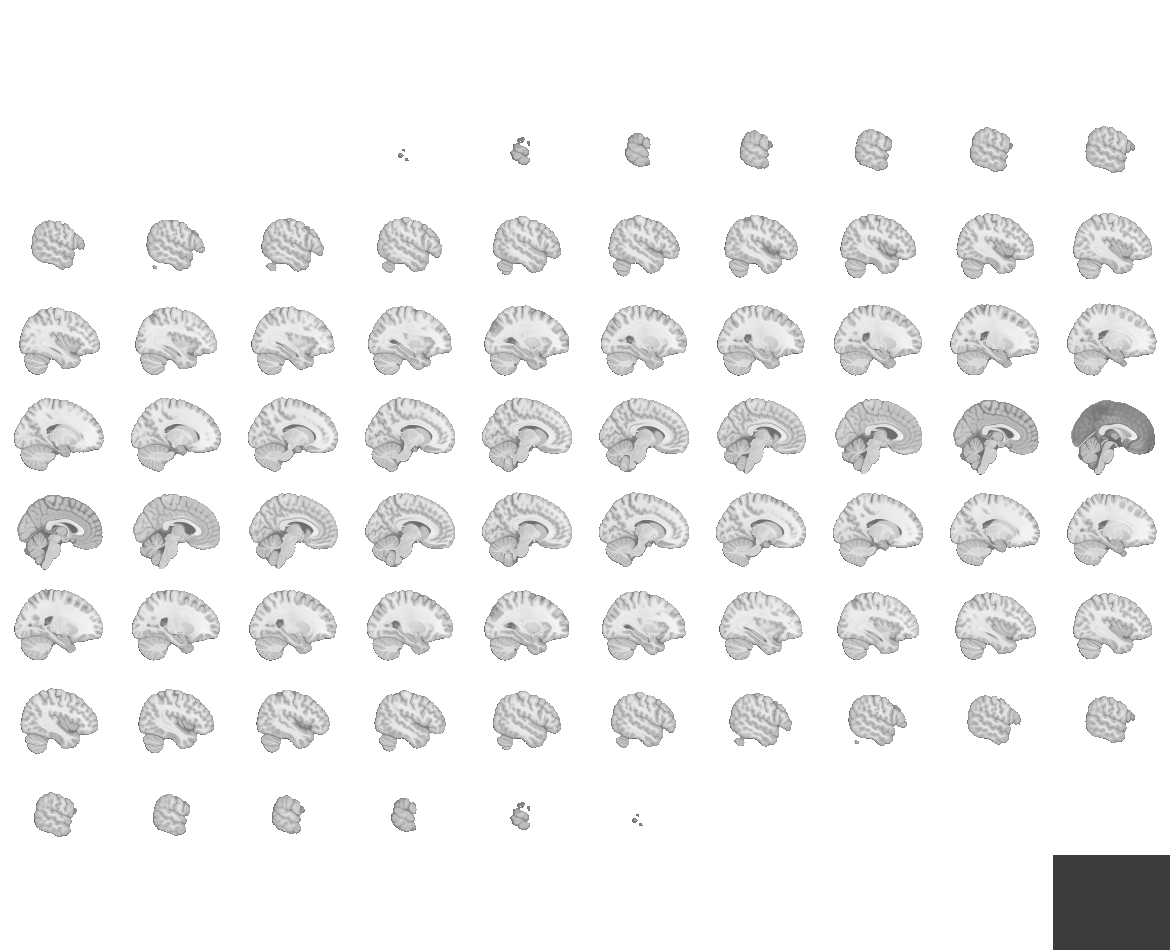
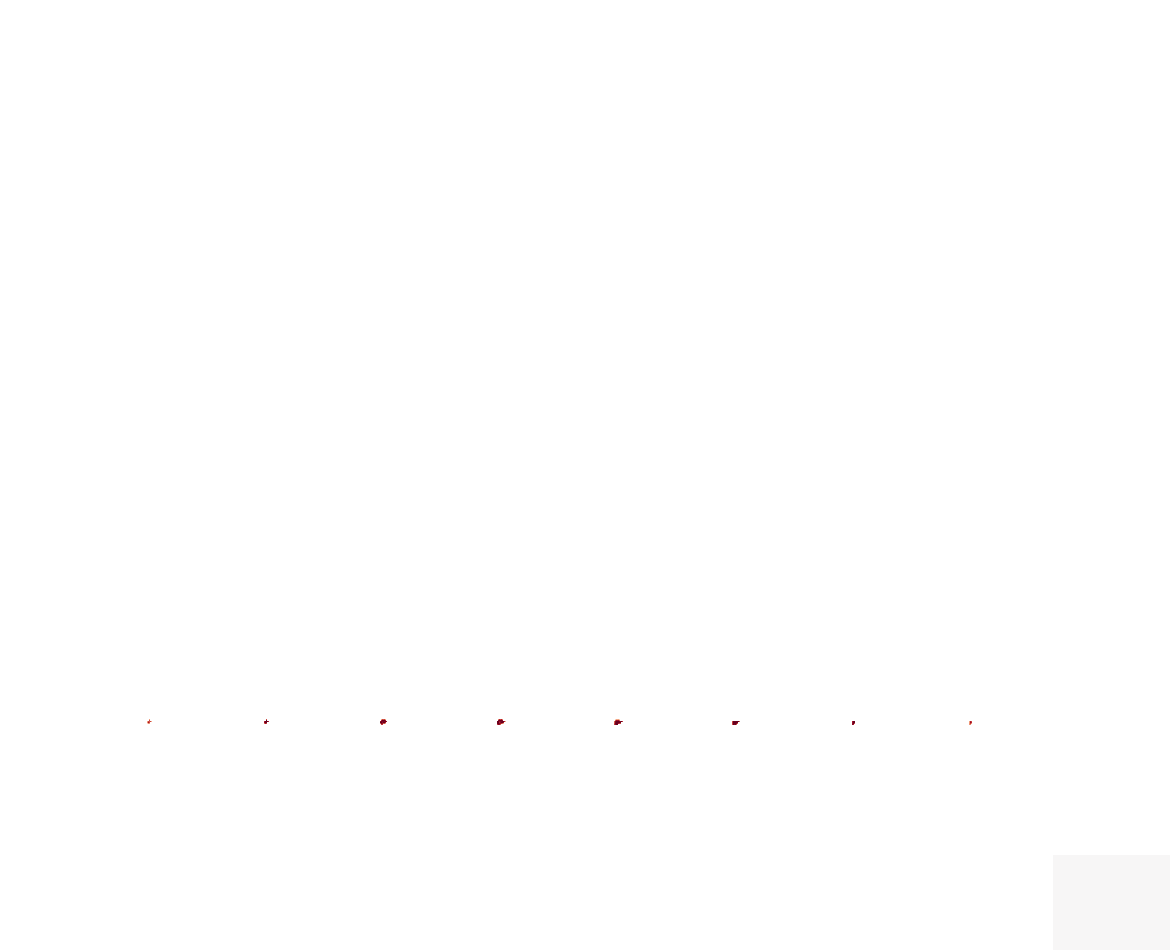


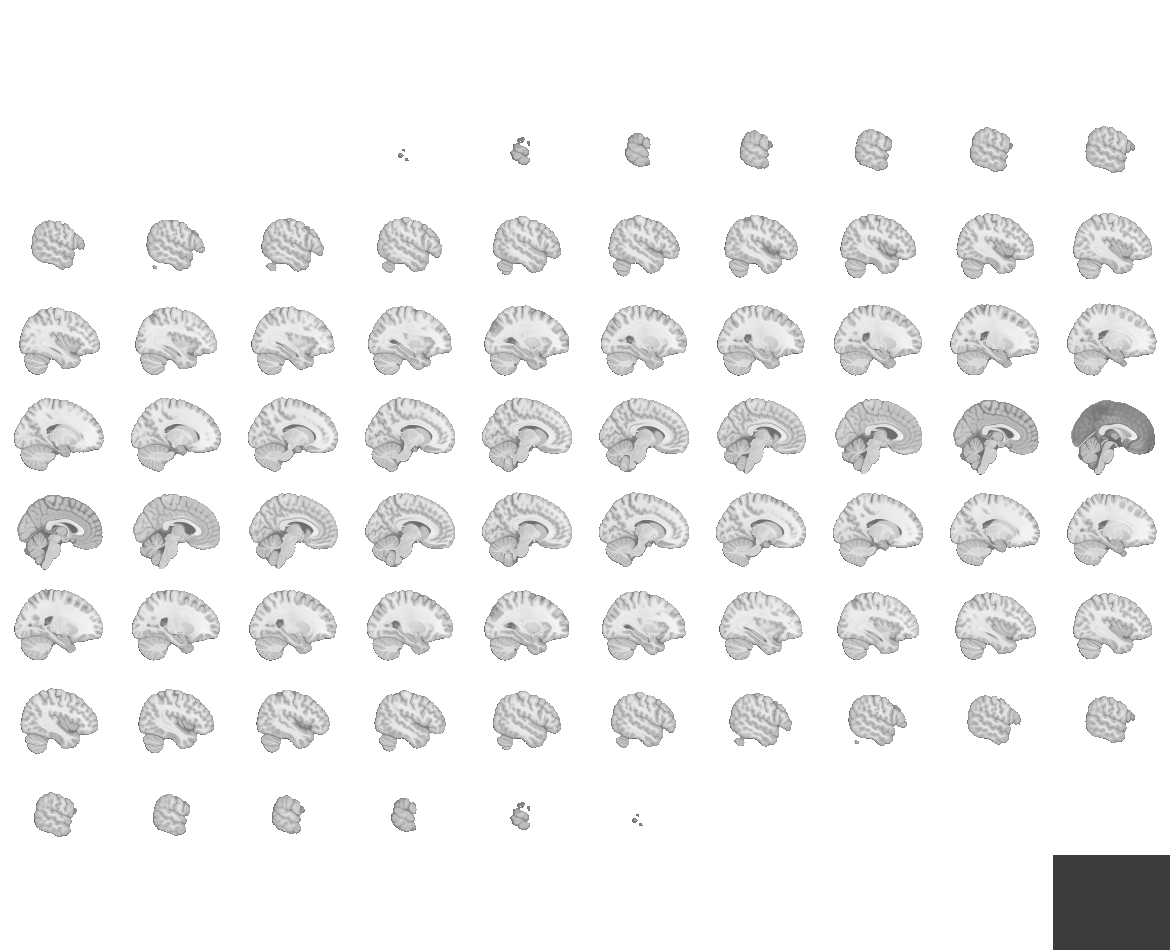
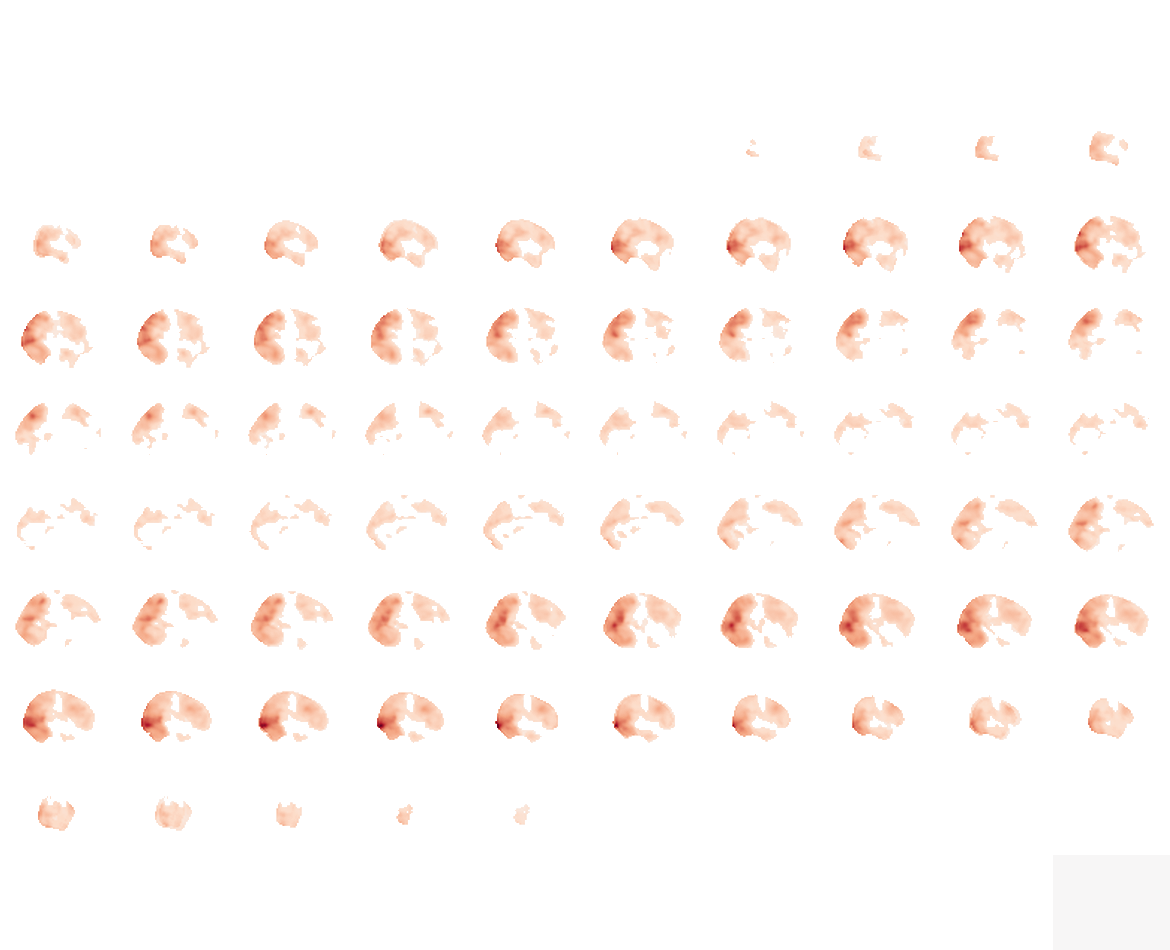


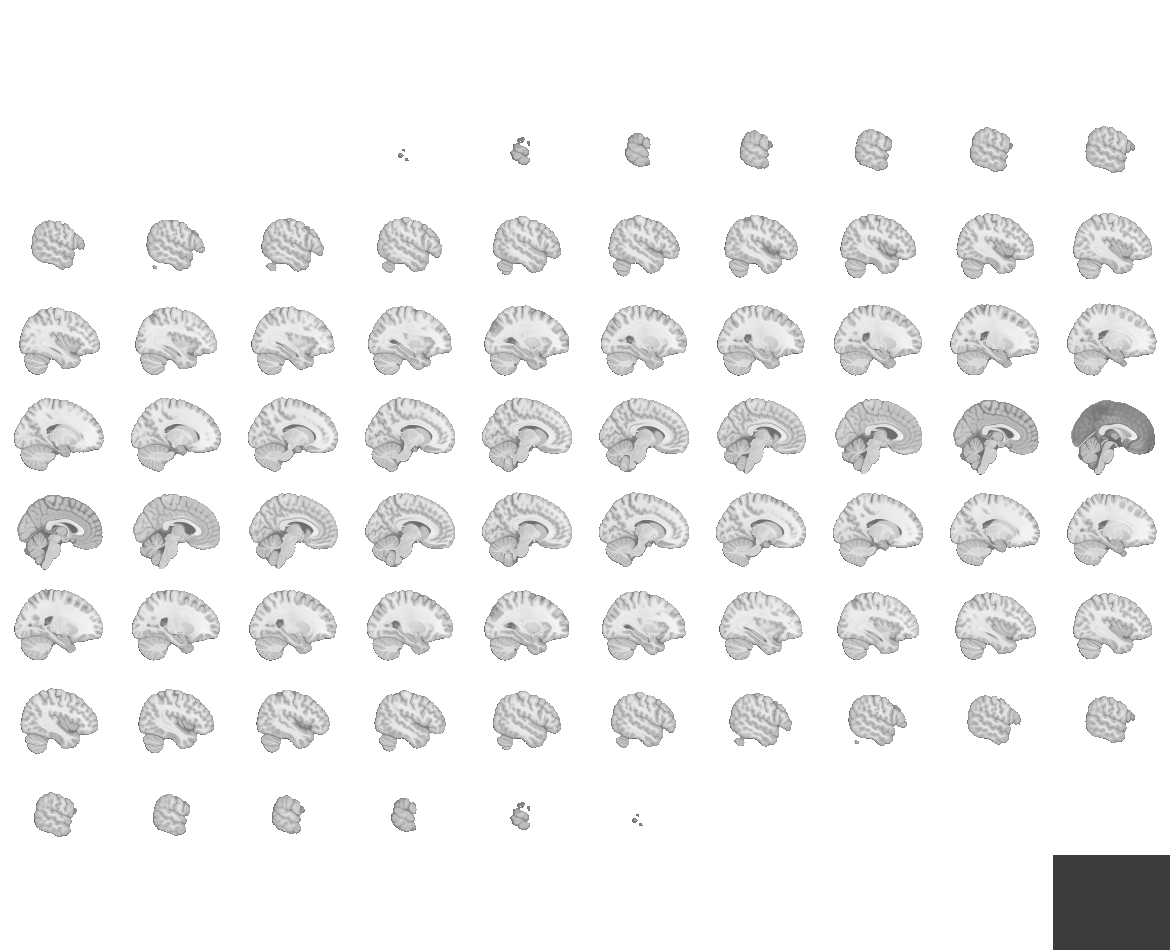
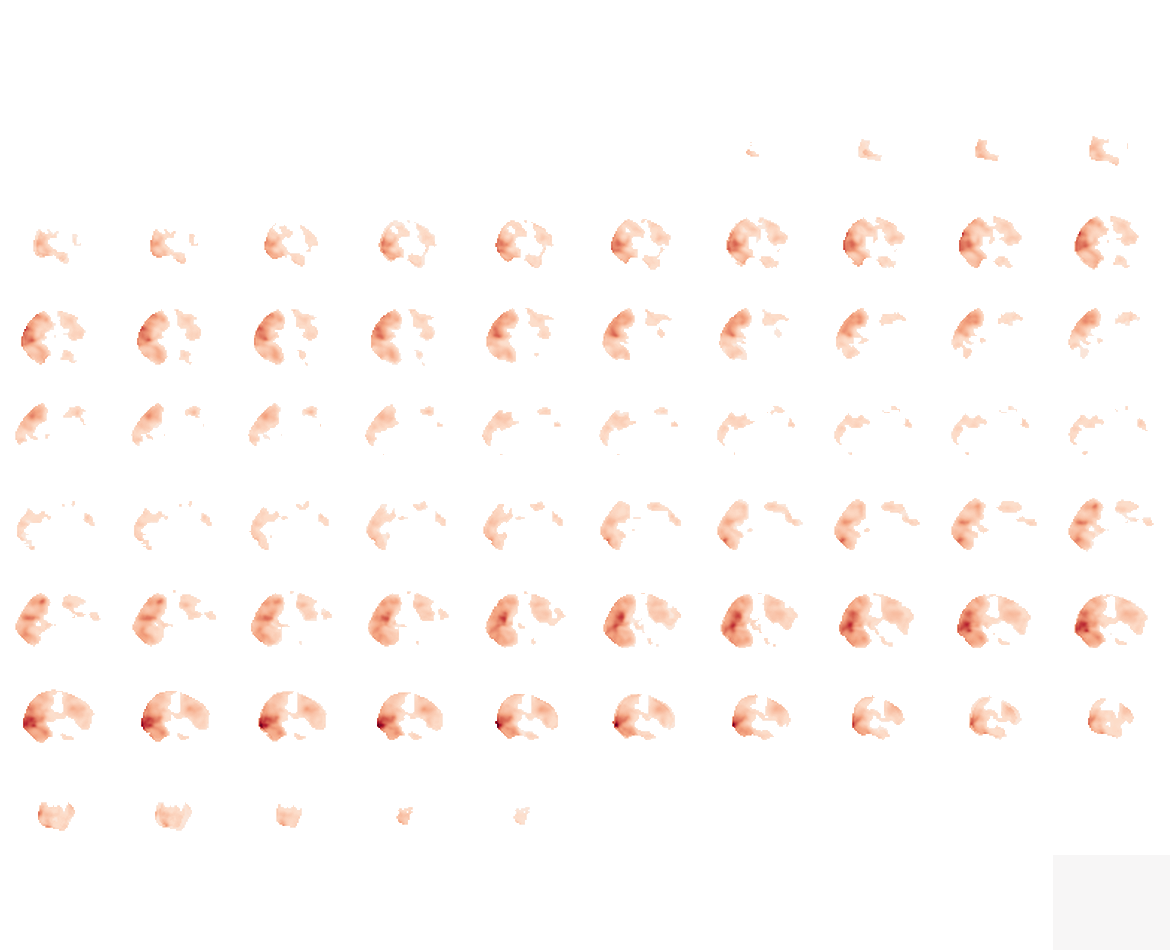


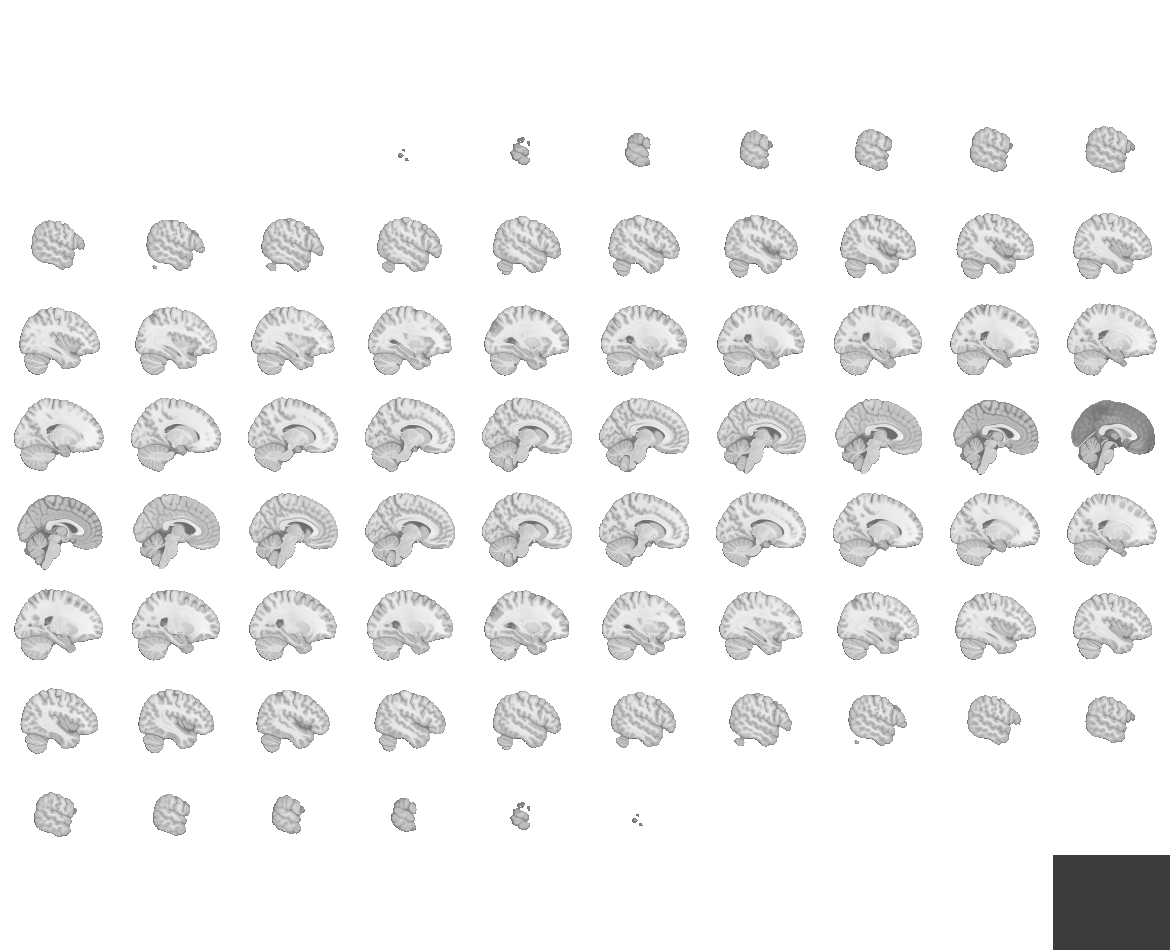
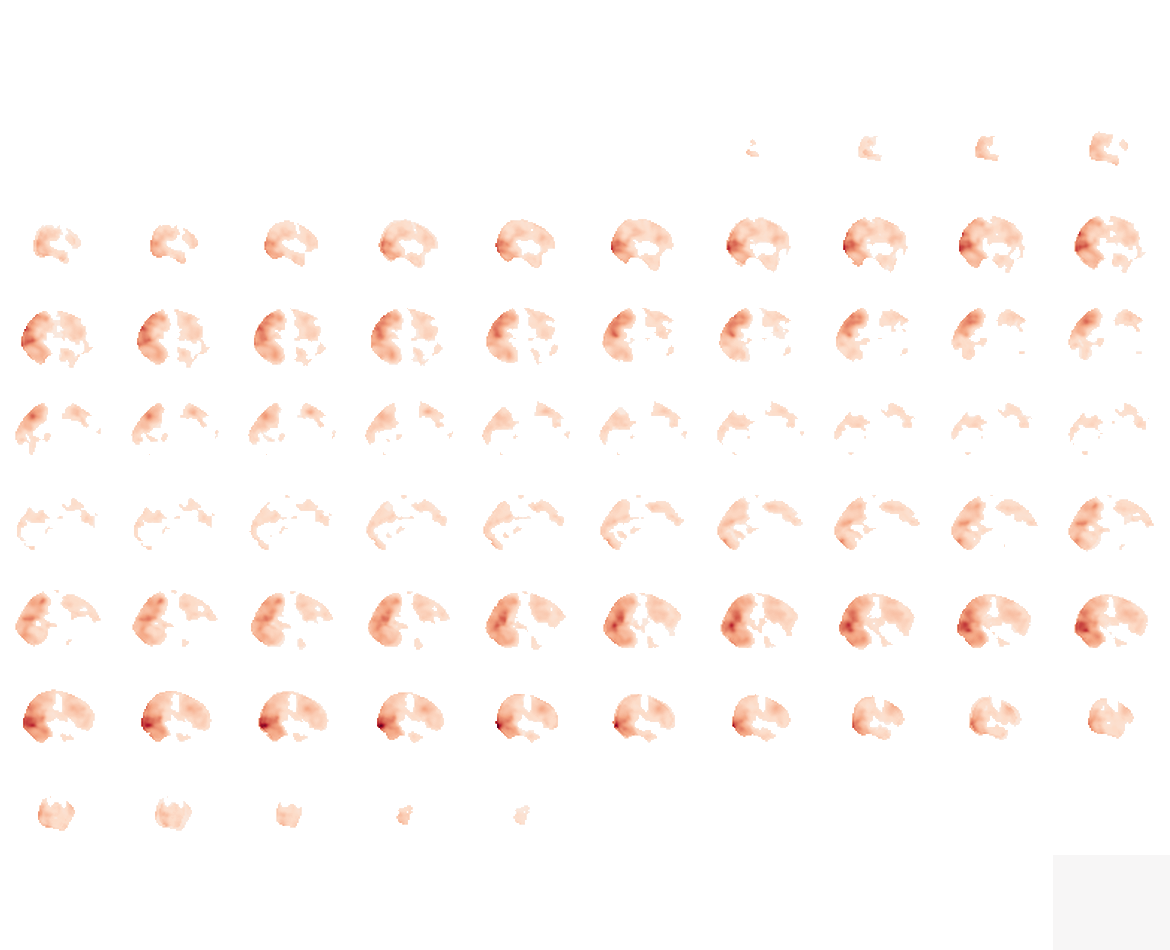

In [31]:
# Interactive glass brain views (FDR 0.001)
for model_name in tmaps:
    tmap = tmaps[model_name][0.001]
    view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,
                             title=f'{model_name} (FDR < 0.001)')
    display(view)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_57492\2205207794.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


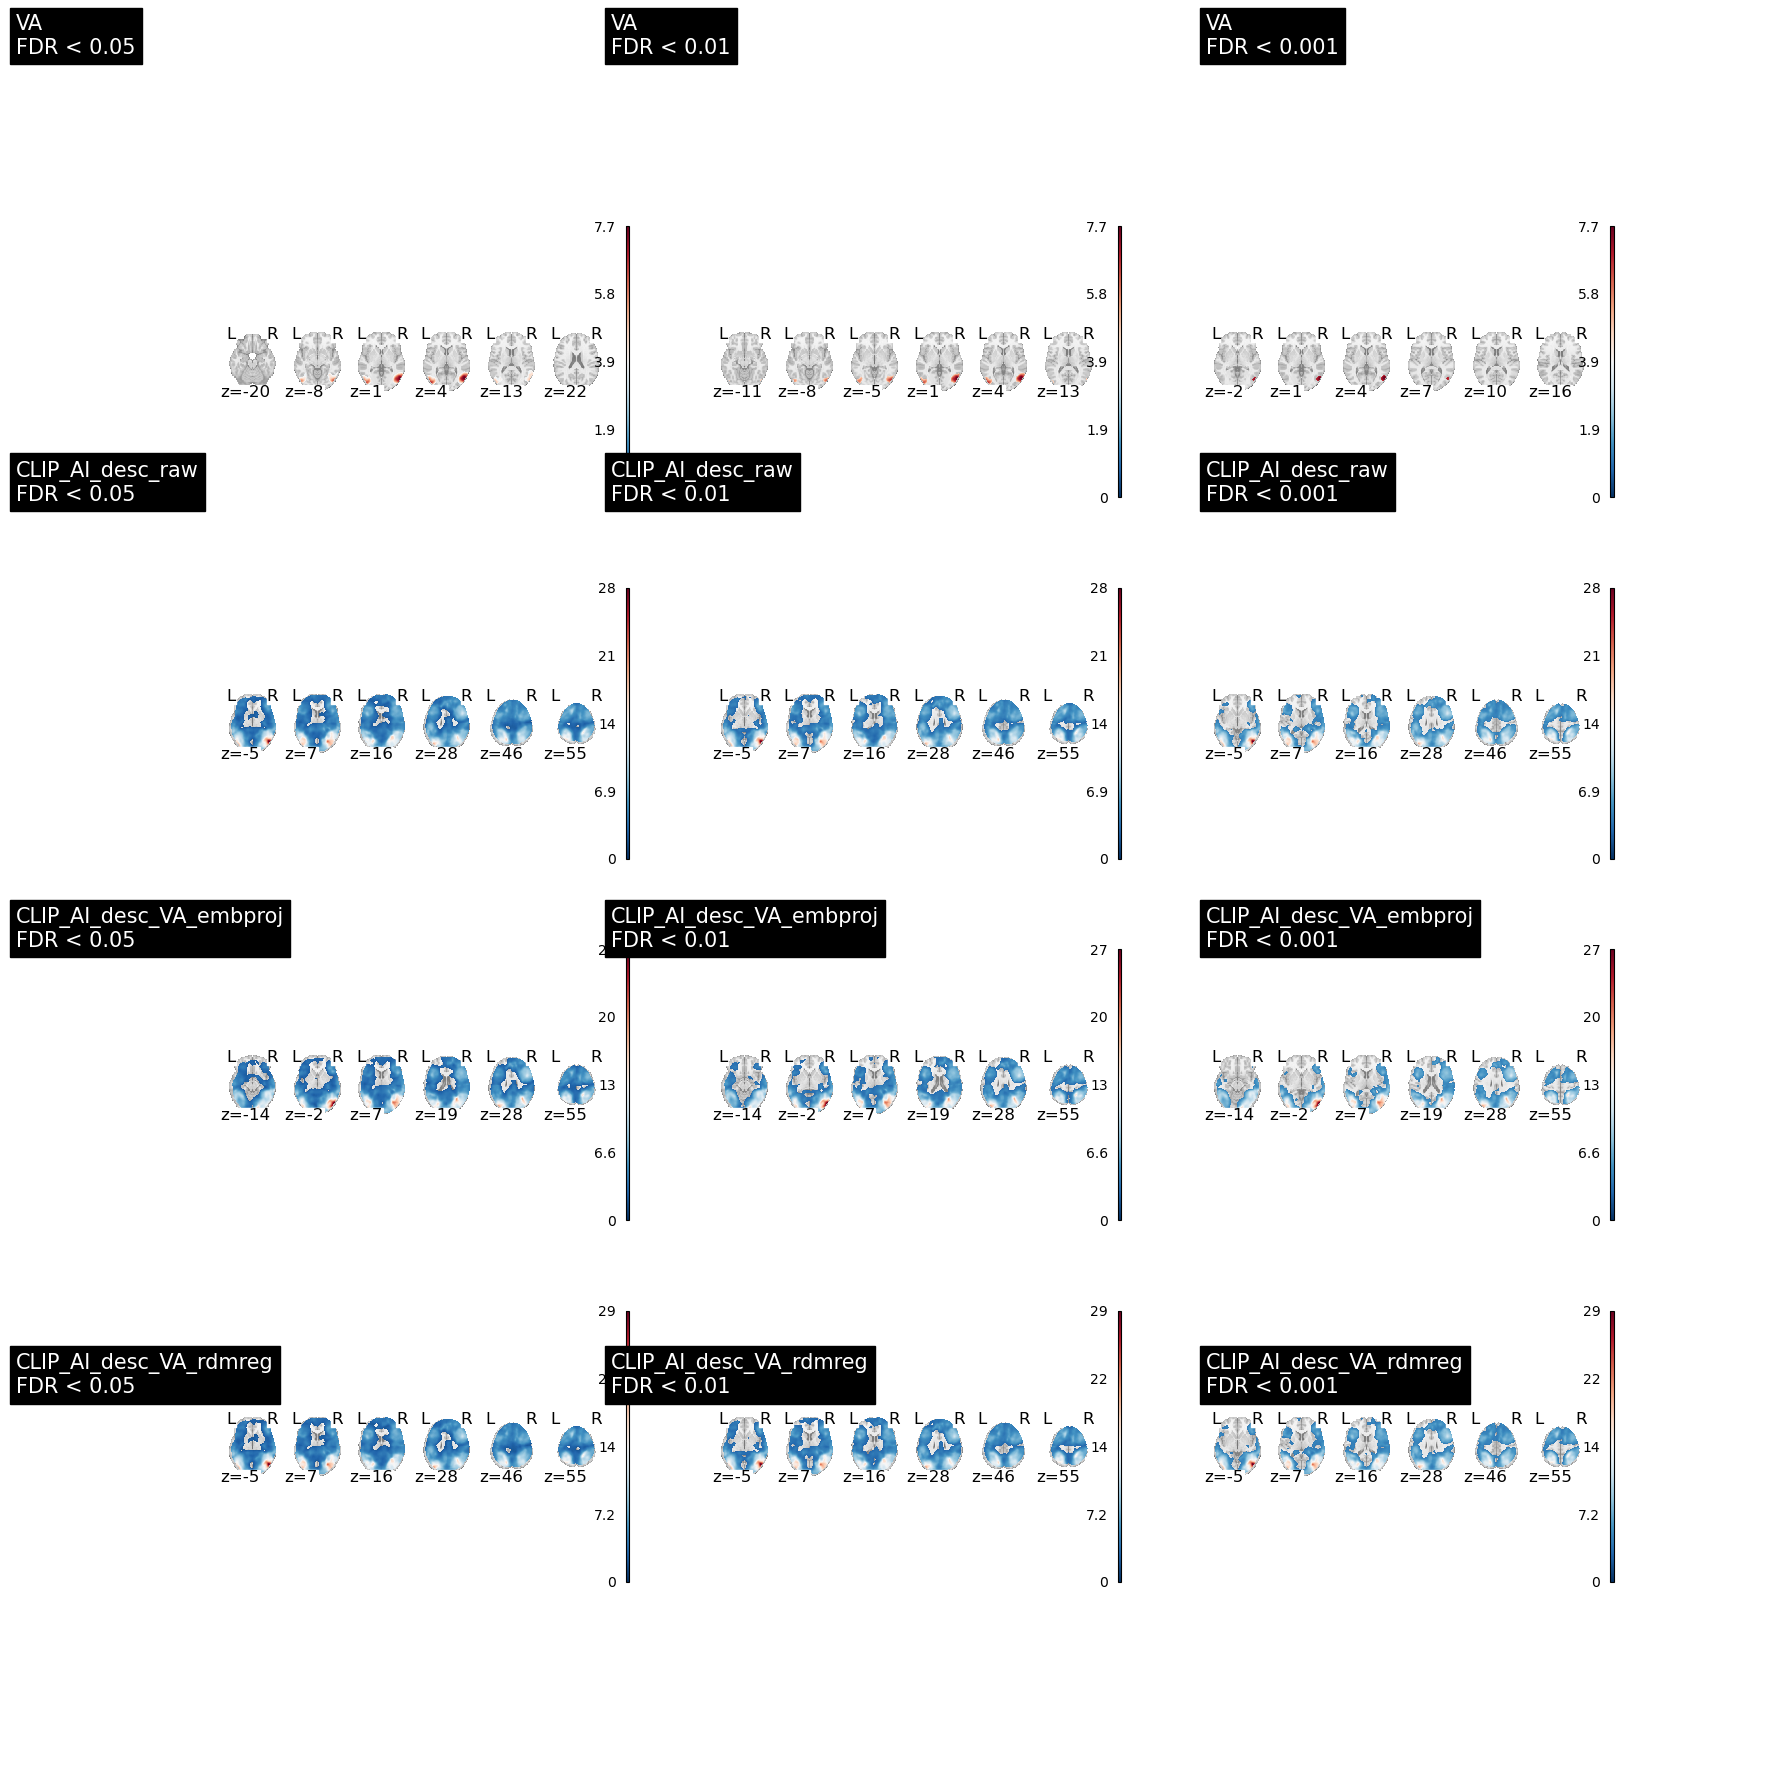

In [32]:
# Static slice views: rows = models, columns = FDR thresholds
model_names = list(tmaps.keys())
n_models = len(model_names)
n_fdrs = len(FDR_ALPHAS)

fig, axes = plt.subplots(n_models, n_fdrs, figsize=(6 * n_fdrs, 4.5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]
if n_fdrs == 1:
    axes = axes[:, np.newaxis]

for row, model_name in enumerate(model_names):
    for col, fdr_alpha in enumerate(FDR_ALPHAS):
        tmap = tmaps[model_name][fdr_alpha]
        plotting.plot_stat_map(
            tmap, display_mode='z', cut_coords=6,
            title=f'{model_name}\nFDR < {fdr_alpha}',
            axes=axes[row, col],
            threshold=0, colorbar=True
        )

plt.tight_layout()
plt.savefig('./outputs/tmap_all_models_all_fdr_slices.png', dpi=150)
plt.show()

## 13. Reload saved results (if restarting)

Uncomment and run if you have already computed the searchlight and just want to reload for visualization.

In [33]:
# # Reload saved results
# model_names = ['VA', 'CLIP_AI_desc_raw', 'CLIP_AI_desc_VA_embproj', 'CLIP_AI_desc_VA_rdmreg']
# results = {}
# for mn in model_names:
#     eval_scores = np.load(f'./outputs/20sub_SL_eval_{mn}.npy')
#     print(f"Reloaded {mn}: {eval_scores.shape}")
#     results[mn] = {'eval_scores': eval_scores, 'voxel_ids': None}
#
# # Recompute searchlight centers for voxel_ids
# # centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)